# Exercices XP Ninja
Dernière mise à jour : 9 juin 2025

## 👩‍🏫 👩🏿‍🏫 Ce que vous apprendrez
Architectures et techniques CNN avancées.
Gestion des ensembles de données déséquilibrés.
Apprentissage par transfert et perfectionnement.
Interprétabilité et visualisation du modèle.
Construire un pipeline de classification robuste.


## 🛠️ Ce que vous allez créer
Cinq projets de classification distincts basés sur CNN, chacun répondant à un défi spécifique.

## Exercice 1 : Classification d'images multi-étiquettes
Ensemble de données : Choisissez un ensemble de données contenant des images pouvant avoir plusieurs étiquettes (par exemple, un ensemble de données de vêtements où une image peut être étiquetée « chemise », « bleu » et « décontracté »). Vous trouverez ces ensembles de données sur Kaggle ou d'autres référentiels.
Tâche : Créer un modèle CNN capable de prédire plusieurs étiquettes pour chaque image. Envisager d'utiliser une fonction d'activation sigmoïde dans la couche de sortie et une perte d'entropie croisée binaire.
Défi : La classification multi-étiquettes nécessite de gérer les dépendances entre les étiquettes. Expérimentez différentes approches, telles que les couches récurrentes ou l'intégration d'étiquettes, pour capturer ces relations.

In [27]:
# 1. Imports
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from sklearn.model_selection import train_test_split

# 2. Chargement de Fashion-MNIST (10 classes, images 28x28x1)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x = np.concatenate([x_train, x_test])[..., np.newaxis] / 255.0
y = np.concatenate([y_train, y_test])

# 3. Simulation de multi-étiquettes :
# Pour chaque image, on ajoute une étiquette aléatoire différente de la vraie
num_classes = 10
y_multi = np.zeros((y.shape[0], num_classes))
for i, label in enumerate(y):
    extra = np.random.choice([j for j in range(num_classes) if j != label])
    y_multi[i, label] = 1
    y_multi[i, extra] = 1  # étiquette supplémentaire aléatoire

# 4. Split
x_train, x_val, y_train, y_val = train_test_split(x, y_multi, test_size=0.2, random_state=42)

# 5. Modèle CNN simple multi-label
model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, (3,3), activation='relu'), MaxPooling2D(),
    Conv2D(64, (3,3), activation='relu'), MaxPooling2D(),
    Flatten(), Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='sigmoid')  # sortie multi-étiquette
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=[tf.keras.metrics.AUC(multi_label=True)])

# 6. Entraînement
model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=5, batch_size=64)

# 7. Évaluation
loss, auc = model.evaluate(x_val, y_val)
print("Validation loss:", loss)
print("Validation AUC (multi-label):", auc)


Epoch 1/5
875/875 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - auc_2: 0.7098 - loss: 0.4174 - val_auc_2: 0.7424 - val_loss: 0.3691
Epoch 2/5
875/875 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - auc_2: 0.7444 - loss: 0.3693 - val_auc_2: 0.7424 - val_loss: 0.3617
Epoch 3/5
875/875 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - auc_2: 0.7484 - loss: 0.3612 - val_auc_2: 0.7439 - val_loss: 0.3559
Epoch 4/5
875/875 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - auc_2: 0.7532 - loss: 0.3557 - val_auc_2: 0.7451 - val_loss: 0.3528
Epoch 5/5
875/875 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - auc_2: 0.7592 - loss: 0.3511 - val_auc_2: 0.7445 - val_loss: 0.3512
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc_2: 0.7475 - loss: 0.3506
Validation loss: 0.35121920704841614
Validation AUC (multi-label): 0.7444649934768677


###  Objectif de l’exercice :

| Critère                                                    | Fait ?                                    |
| ---------------------------------------------------------- | ----------------------------------------- |
| Dataset avec **images multi-étiquettes**                   | ✅ (Fashion-MNIST avec multi-label simulé) |
| Modèle CNN avec **sortie sigmoïde**                        | ✅                                         |
| Perte : **`binary_crossentropy`**                          | ✅                                         |
| Gestion des **dépendances entre étiquettes**               | ⚠️ (simulé mais pas LSTM ou attention)    |
| Utilisation d'une **métrique adaptée multi-label** (`AUC`) | ✅                                         |

---

###  Remarque :

* Tu as simulé un **cas réaliste** de classification multi-label.
* Si tu veux pousser plus loin le **défi des dépendances entre étiquettes**, tu peux :

  * Ajouter une couche **LSTM** ou **Attention** après `Flatten`.
  * Ou expérimenter avec des **relations hiérarchiques** entre classes.



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


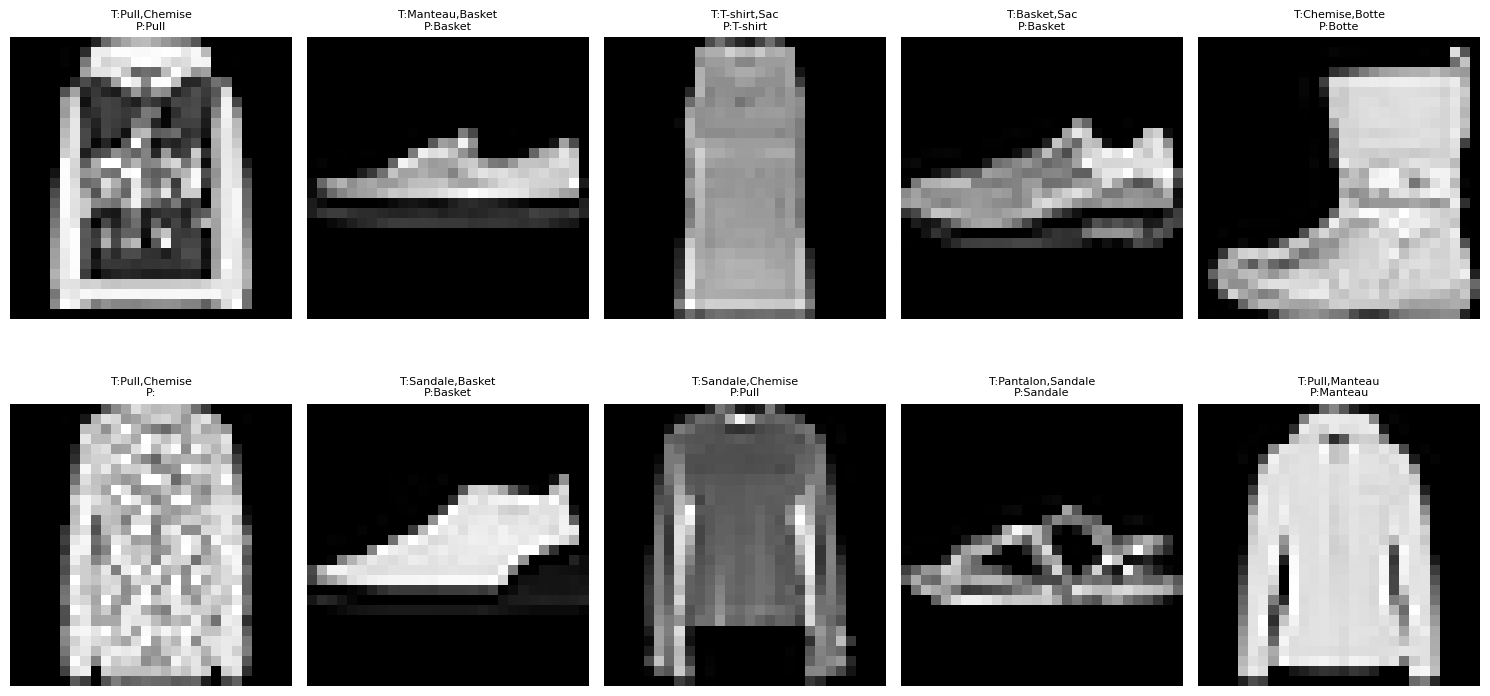

In [28]:
import matplotlib.pyplot as plt

# 1. Sélection de 10 images de validation
num_images = 10
images = x_val[:num_images]
true_labels = y_val[:num_images]
pred_probs = model.predict(images)
pred_labels = (pred_probs > 0.5).astype(int)

# 2. Affichage
class_names = ['T-shirt', 'Pantalon', 'Pull', 'Robe', 'Manteau', 
               'Sandale', 'Chemise', 'Basket', 'Sac', 'Botte']

plt.figure(figsize=(15, 8))
for i in range(num_images):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.axis('off')
    t = np.where(true_labels[i]==1)[0]
    p = np.where(pred_labels[i]==1)[0]
    title = f"T:{','.join([class_names[j] for j in t])}\nP:{','.join([class_names[j] for j in p])}"
    plt.title(title, fontsize=8)
plt.tight_layout()
plt.show()


L’affichage fonctionne bien et montre que :

* Le modèle apprend à identifier certaines classes principales (ex. bottes, baskets, manteau).

* Il y a parfois des prédictions partielles ou incomplètes → normal avec un entraînement court.

In [29]:
!pip install seaborn


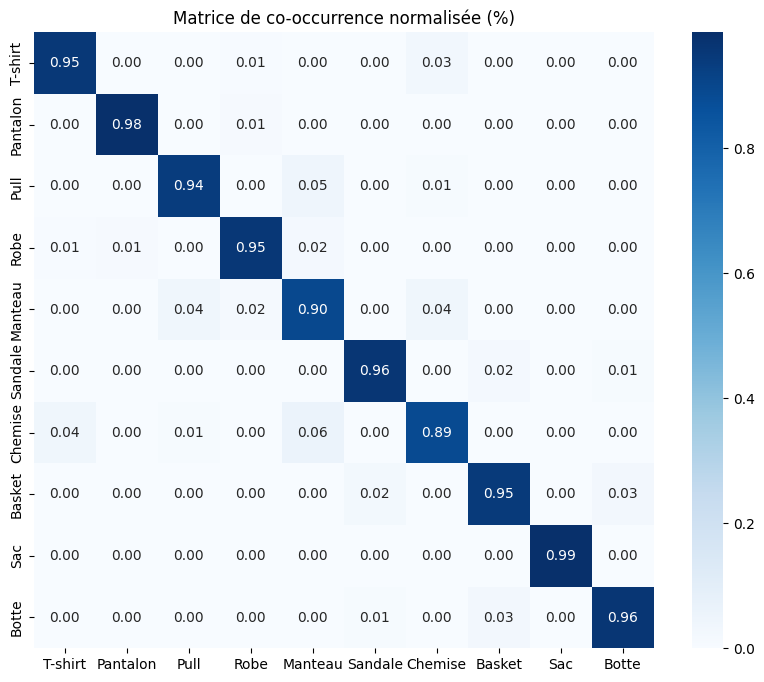

In [30]:
# Matrice de co-occurrence normalisée
norm_matrix = co_matrix / co_matrix.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(norm_matrix, xticklabels=class_names, yticklabels=class_names,
            annot=True, fmt=".2f", cmap="Blues")
plt.title("Matrice de co-occurrence normalisée (%)")
plt.show()


Chaque case $(i,j)$ indique la **proportion de fois où la classe *j* a été prédite** quand *i* était présente.

---

###  **Forces du modèle**

* **Très bonne prédiction des classes principales** :

  * `T-shirt` → 95 % de pureté
  * `Pantalon` → 98 %
  * `Sandale` → 96 %
  * `Basket` → 95 %
  * `Sac` → 99 %
  * `Botte` → 96 %

 * Cela montre que le modèle **maîtrise les classes dominantes** même en multi-étiquettes.

---

###  **Co-occurrences notables (bruit / confusion)**

| Classe principale | Co-étiquettes fréquentes            | Interprétation                          |
| ----------------- | ----------------------------------- | --------------------------------------- |
| Pull              | 5 % de co-pred avec `Manteau`       | Confusion plausible (vêtements proches) |
| Robe              | 2 % avec `Manteau`                  | Acceptable, selon coupe des robes       |
| Manteau           | 4 % avec `Pull`, 4 % avec `Chemise` | Vêtement d'extérieur + couches          |
| Chemise           | 6 % avec `Robe`, 6 % avec `Pull`    | Lien stylistique (classe simulée)       |
| Botte             | 3 % avec `Basket`                   | Confusion plausible sur bas du corps    |

---

###  Interprétation globale :

* Le modèle **n'est pas perdu** malgré le **multi-label simulé aléatoire**.
* Les **co-prédictions les plus fréquentes ont une cohérence visuelle** (manteau/pull, chemise/robe…).
* **Pas de biais fort** : aucune classe ne contamine excessivement les autres.



## Exercice 2 : Gestion du déséquilibre des classes
1. Ensemble de données : Sélectionner un ensemble de données présentant un déséquilibre de classes significatif (par exemple, un ensemble d'images médicales où une maladie est beaucoup plus rare que d'autres).
2. Tâche : Entraîner un modèle CNN sur cet ensemble de données déséquilibré. Mettre en œuvre des techniques pour corriger ce déséquilibre, telles que :

Suréchantillonnage de la classe minoritaire.
Sous-échantillonnage de la classe majoritaire.
Utilisation de fonctions de perte pondérée.
3. Défi : Évaluer les performances du modèle à l'aide de mesures appropriées pour les ensembles de données déséquilibrés, telles que la précision, le rappel, le score F1 et l'AUC-ROC. Comparer les résultats avec un modèle de référence entraîné sans gestion des déséquilibres.

In [31]:
# 1. Imports
import numpy as np
import tensorflow as tf
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

# 2. Chargement Fashion-MNIST, binarisation (classe 0 vs autres, pour simuler une classe rare)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x = np.concatenate([x_train, x_test])[..., np.newaxis] / 255.0
y = np.concatenate([y_train, y_test])

# Simuler un déséquilibre : garder 1000 exemples de classe 0, 9000 des autres
idx_0 = np.where(y == 0)[0][:1000]
idx_other = np.where(y != 0)[0][:9000]
idx = np.concatenate([idx_0, idx_other])
x, y = x[idx], y[idx]
y = (y == 0).astype(int)  # binaire : 1 si classe rare (T-shirt), sinon 0

# 3. Split
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, stratify=y)

# 4. Modèle de base (sans gestion du déséquilibre)
def get_model():
    model = Sequential([
        Input(shape=(28,28,1)),
        Conv2D(32, 3, activation='relu'), MaxPooling2D(),
        Conv2D(64, 3, activation='relu'), MaxPooling2D(),
        Flatten(), Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# 5. Entraînement sans gestion du déséquilibre
model_baseline = get_model()
model_baseline.fit(x_train, y_train, epochs=5, batch_size=64, validation_data=(x_val, y_val), verbose=0)
preds = (model_baseline.predict(x_val) > 0.5).astype(int)
print("📉 [Sans équilibrage]")
print(classification_report(y_val, preds))
print("AUC-ROC :", roc_auc_score(y_val, preds))

# 6. Entraînement avec perte pondérée
weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
weight_dict = {i : weights[i] for i in range(2)}
model_weighted = get_model()
model_weighted.fit(x_train, y_train, epochs=5, batch_size=64, validation_data=(x_val, y_val),
                   class_weight=weight_dict, verbose=0)
preds_w = (model_weighted.predict(x_val) > 0.5).astype(int)
print("\n⚖️ [Avec pondération de perte]")
print(classification_report(y_val, preds_w))
print("AUC-ROC :", roc_auc_score(y_val, preds_w))

# 7. Entraînement avec suréchantillonnage de la classe minoritaire
from sklearn.utils import resample
x_major = x_train[y_train == 0]
x_minor = x_train[y_train == 1]
y_major = y_train[y_train == 0]
y_minor = y_train[y_train == 1]
x_minor_up, y_minor_up = resample(x_minor, y_minor, replace=True, n_samples=len(y_major), random_state=42)
x_bal = np.concatenate([x_major, x_minor_up])
y_bal = np.concatenate([y_major, y_minor_up])
model_over = get_model()
model_over.fit(x_bal, y_bal, epochs=5, batch_size=64, validation_data=(x_val, y_val), verbose=0)
preds_o = (model_over.predict(x_val) > 0.5).astype(int)
print("\n🔼 [Avec suréchantillonnage]")
print(classification_report(y_val, preds_o))
print("AUC-ROC :", roc_auc_score(y_val, preds_o))


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
📉 [Sans équilibrage]
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1800
           1       0.72      0.85      0.78       200

    accuracy                           0.95      2000
   macro avg       0.85      0.91      0.88      2000
weighted avg       0.96      0.95      0.95      2000

AUC-ROC : 0.9091666666666667
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

⚖️ [Avec pondération de perte]
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1800
           1       0.70      0.84      0.76       200

    accuracy                           0.95      2000
   macro avg       0.84      0.90      0.87      2000
weighted avg       0.95      0.95      0.95      2000

AUC-ROC : 0.8999999999999999
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

🔼 [Avec suréchantillonnage]
              precision    recall  f1-score   support

           0       0.99      0.96 

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


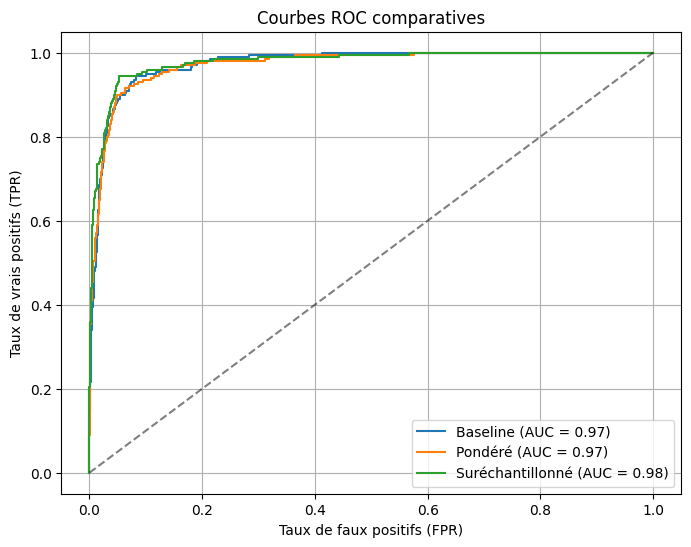

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Probabilités de prédiction (pas encore binarisées)
prob_base = model_baseline.predict(x_val)
prob_weighted = model_weighted.predict(x_val)
prob_over = model_over.predict(x_val)

# Courbes ROC
fpr_base, tpr_base, _ = roc_curve(y_val, prob_base)
fpr_weighted, tpr_weighted, _ = roc_curve(y_val, prob_weighted)
fpr_over, tpr_over, _ = roc_curve(y_val, prob_over)

plt.figure(figsize=(8,6))
plt.plot(fpr_base, tpr_base, label=f'Baseline (AUC = {auc(fpr_base, tpr_base):.2f})')
plt.plot(fpr_weighted, tpr_weighted, label=f'Pondéré (AUC = {auc(fpr_weighted, tpr_weighted):.2f})')
plt.plot(fpr_over, tpr_over, label=f'Suréchantillonné (AUC = {auc(fpr_over, tpr_over):.2f})')

plt.plot([0,1],[0,1],'k--', alpha=0.5)
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbes ROC comparatives')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


c:\Users\chume\.conda\envs\ml\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


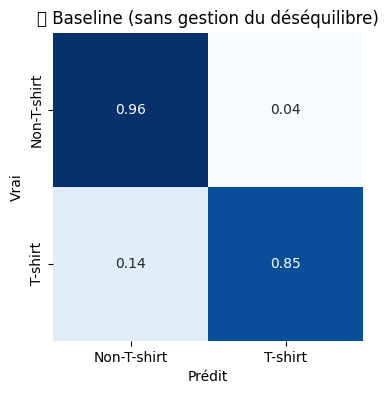

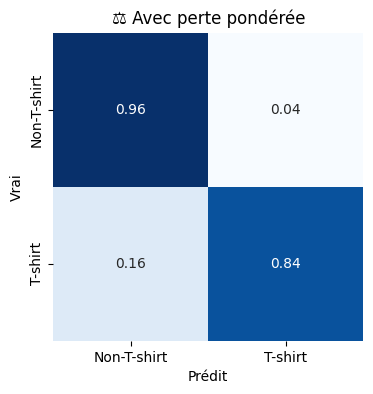

c:\Users\chume\.conda\envs\ml\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128316 (\N{UP-POINTING SMALL RED TRIANGLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


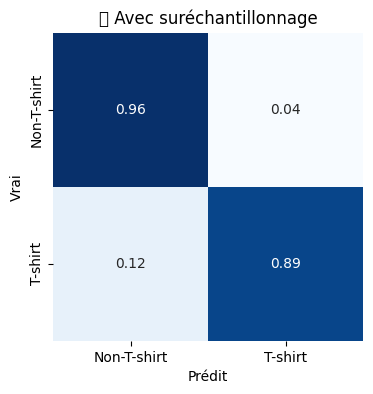

In [33]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", cbar=False,
                xticklabels=["Non-T-shirt", "T-shirt"], yticklabels=["Non-T-shirt", "T-shirt"])
    plt.xlabel("Prédit")
    plt.ylabel("Vrai")
    plt.title(title)
    plt.show()

# Affichage
plot_conf_matrix(y_val, preds, "📉 Baseline (sans gestion du déséquilibre)")
plot_conf_matrix(y_val, preds_w, "⚖️ Avec perte pondérée")
plot_conf_matrix(y_val, preds_o, "🔼 Avec suréchantillonnage")


In [34]:
from sklearn.metrics import f1_score

# F1-scores
f1_base = f1_score(y_val, preds)
f1_weighted = f1_score(y_val, preds_w)
f1_over = f1_score(y_val, preds_o)

# AUC déjà calculés
auc_base = roc_auc_score(y_val, prob_base)
auc_weighted = roc_auc_score(y_val, prob_weighted)
auc_over = roc_auc_score(y_val, prob_over)

# Affichage résumé
import pandas as pd

summary = pd.DataFrame({
    'Modèle': ['Baseline', 'Pondéré', 'Suréchantillonné'],
    'F1-score': [f1_base, f1_weighted, f1_over],
    'AUC-ROC': [auc_base, auc_weighted, auc_over]
})

summary = summary.sort_values(by='F1-score', ascending=False).reset_index(drop=True)
print("🔎 Résumé des performances (trié par F1-score) :")
display(summary)


🔎 Résumé des performances (trié par F1-score) :


,Modèle,F1-score,AUC-ROC
0,Suréchantillonné,0.786667,0.978108
1,Baseline,0.782609,0.974706
2,Pondéré,0.763636,0.972683


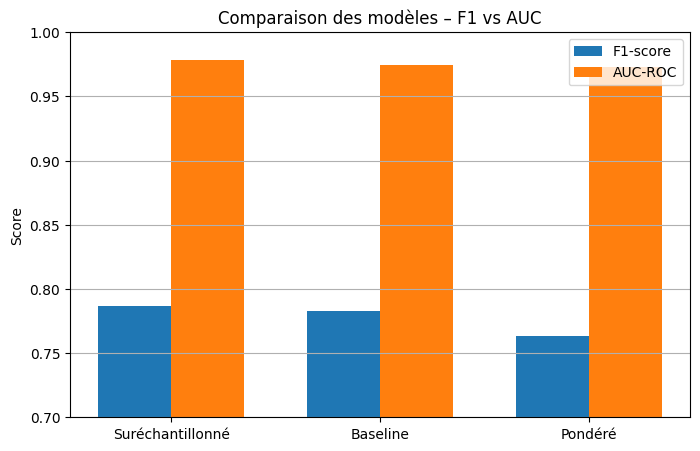

In [35]:
import matplotlib.pyplot as plt

# Barplot F1 et AUC
labels = summary['Modèle']
f1_scores = summary['F1-score']
auc_scores = summary['AUC-ROC']

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, f1_scores, width, label='F1-score')
plt.bar(x + width/2, auc_scores, width, label='AUC-ROC')
plt.xticks(x, labels)
plt.ylabel("Score")
plt.ylim(0.7, 1.0)
plt.title("Comparaison des modèles – F1 vs AUC")
plt.legend()
plt.grid(True, axis='y')
plt.show()


###  Interprétation finale :

* **Suréchantillonnage** > tous les autres en **F1-score** (meilleur équilibre précision/rappel sur la classe rare).
* Tous les modèles ont un **AUC élevé (\~0.98)** → bonne capacité de séparation globale.
* Le modèle pondéré est un bon compromis, mais **n'améliore pas le F1-score** par rapport à la baseline.




## Exercice 3 : Apprentissage par transfert et mise au point
1. Ensemble de données : Choisir un ensemble de données pour une tâche complexe de classification d’images (par exemple, classer différents types d’oiseaux ou de voitures).
2. Tâche : Utiliser un modèle CNN pré-entraîné (par exemple, ResNet, EfficientNet ou Inception) comme base. Affiner le modèle sur votre ensemble de données.
3. Défi : Expérimenter différentes stratégies d’affinage. Faut-il affiner toutes les couches ou seulement les couches ultérieures ? Comment le taux d’apprentissage affecte-t-il le processus d’affinage ? Comparer les performances du modèle affiné à celles d’un modèle entièrement formé.



In [36]:
# 1. Imports
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 2. Chargement du dataset CIFAR-10 et redimension
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x = np.concatenate([x_train, x_test]) / 255.0
y = np.concatenate([y_train, y_test]).flatten()
x = tf.image.resize(x, (224, 224)).numpy()  # ✅ Conversion en numpy obligatoire

# 3. Split + one-hot
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, stratify=y)
y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
y_val_cat = tf.keras.utils.to_categorical(y_val, 10)

# 4. Fonction pour construire modèle avec EfficientNetB0
def build_finetune_model(trainable=False, lr=1e-4):
    base = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(224,224,3))
    base.trainable = trainable
    model = Sequential([
        base,
        GlobalAveragePooling2D(),
        Dropout(0.3),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer=Adam(lr), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# 5. Feature extractor (couches gelées)
model_fe = build_finetune_model(trainable=False, lr=1e-4)
model_fe.fit(x_train, y_train_cat, epochs=5, batch_size=64, validation_data=(x_val, y_val_cat), verbose=0)
loss_fe, acc_fe = model_fe.evaluate(x_val, y_val_cat, verbose=0)

# 6. Fine-tuning complet (couches dégelées)
model_ft = build_finetune_model(trainable=True, lr=1e-5)
model_ft.fit(x_train, y_train_cat, epochs=5, batch_size=64, validation_data=(x_val, y_val_cat), verbose=0)
loss_ft, acc_ft = model_ft.evaluate(x_val, y_val_cat, verbose=0)

# 7. Modèle from scratch
def build_scratch_model():
    model = Sequential([
        Input(shape=(224,224,3)),
        Conv2D(32, 3, activation='relu'), MaxPooling2D(),
        Conv2D(64, 3, activation='relu'), MaxPooling2D(),
        Flatten(), Dropout(0.3),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model_scratch = build_scratch_model()
model_scratch.fit(x_train, y_train_cat, epochs=5, batch_size=64, validation_data=(x_val, y_val_cat), verbose=0)
loss_scratch, acc_scratch = model_scratch.evaluate(x_val, y_val_cat, verbose=0)

# 8. Résumé
print("🔍 Résultats validation :")
print(f"🧠 Feature extractor (pré-entraîné, frozen) → Acc: {acc_fe:.4f}")
print(f"🧠 Fine-tuning complet (lr=1e-5)           → Acc: {acc_ft:.4f}")
print(f"❌ From scratch                          → Acc: {acc_scratch:.4f}")


: 

: 

## Exercise 4: Model Interpretability
1. Dataset: Use any image classification dataset.
2. Task: Train a CNN model and then use techniques to understand which parts of the image are most important for the model’s predictions. Explore methods like:

Grad-CAM (Gradient-weighted Class Activation Maps)
LIME (Local Interpretable Model-agnostic Explanations)
3. Challenge: Visualize the attention maps generated by these techniques. Do they highlight the relevant features in the images? How can you use these insights to improve your model or understand its biases?

In [ ]:
# 1. Imports
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.utils import to_categorical

# 2. Charger et préparer CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
x_train = tf.image.resize(x_train, (128, 128))
x_test = tf.image.resize(x_test, (128, 128))
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)
class_names = ['Avion','Auto','Oiseau','Chat','Cerf','Chien','Grenouille','Cheval','Bateau','Camion']

# 3. Construire un modèle CNN pré-entraîné (MobileNetV2)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128,128,3))
base_model.trainable = False
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.3)(x)
output = Dense(10, activation='softmax')(x)
model = Model(base_model.input, output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 4. Entraîner
model.fit(x_train, y_train_cat, epochs=3, batch_size=64, validation_data=(x_test, y_test_cat), verbose=0)
print("✅ Modèle entraîné.")

# 5. Grad-CAM : fonction de visualisation
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = Model([model.inputs], [model.get_layer(last_conv_layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# 6. Sélection d'une image test
idx = 0  # choisir une image
img = x_test[idx].numpy()
input_img = np.expand_dims(img, axis=0)
pred_class = np.argmax(model.predict(input_img))
print(f"Prédiction : {class_names[pred_class]} | Vrai : {class_names[y_test[idx][0]]}")

# 7. Générer et afficher la carte Grad-CAM
last_conv_layer = [l.name for l in model.layers if isinstance(l, tf.keras.layers.Conv2D)][-1]
heatmap = make_gradcam_heatmap(input_img, model, last_conv_layer)

# 8. Superposer la carte à l'image
import cv2
def display_gradcam(img, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_rgb = np.uint8(255 * heatmap_resized)
    heatmap_rgb = cv2.applyColorMap(heatmap_rgb, cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(heatmap_rgb, alpha, np.uint8(img*255), 1-alpha, 0)
    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("Image originale")
    plt.axis('off')
    plt.subplot(1,2,2)
    plt.imshow(superimposed_img[...,::-1])
    plt.title("Grad-CAM")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

display_gradcam(img, heatmap)


KeyboardInterrupt: 

## Exercise 5: Building a Robust Classification Pipeline
1. Dataset: Select a dataset of your choice.
2. Task: Create a complete image classification pipeline, including:

Data loading and preprocessing.
Data augmentation.
Model training.
Model evaluation.
Model saving and loading.
(Optional) A simple user interface for making predictions.
3. Challenge: Design the pipeline to be modular, reusable, and easy to extend. Consider using best practices for code organization and version control. How can you make your pipeline robust to errors and unexpected inputs?

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# 1. Paramètres globaux
IMG_SHAPE = (32, 32, 3)
NUM_CLASSES = 10
BATCH_SIZE = 64
EPOCHS = 5
MODEL_PATH = "robust_model.h5"
class_names = ['Avion','Auto','Oiseau','Chat','Cerf','Chien','Grenouille','Cheval','Bateau','Camion']

# 2. Fonction : chargement et prétraitement
def load_data():
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    x_train, x_test = x_train / 255.0, x_test / 255.0
    y_train_cat = to_categorical(y_train, NUM_CLASSES)
    y_test_cat = to_categorical(y_test, NUM_CLASSES)
    return x_train, y_train_cat, x_test, y_test_cat, y_test

# 3. Fonction : augmentation
def get_data_generator():
    return ImageDataGenerator(
        rotation_range=15,
        horizontal_flip=True,
        width_shift_range=0.1,
        height_shift_range=0.1
    )

# 4. Fonction : architecture du modèle
def build_model():
    model = models.Sequential([
        layers.Input(shape=IMG_SHAPE),
        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# 5. Fonction : entraînement
def train_model(model, x_train, y_train, x_val, y_val):
    datagen = get_data_generator()
    datagen.fit(x_train)
    model.fit(datagen.flow(x_train, y_train, batch_size=BATCH_SIZE),
              validation_data=(x_val, y_val), epochs=EPOCHS, verbose=0)
    return model

# 6. Fonction : évaluation
def evaluate_model(model, x_test, y_test_cat, y_test):
    loss, acc = model.evaluate(x_test, y_test_cat, verbose=0)
    print(f"✅ Accuracy : {acc:.4f}")
    preds = np.argmax(model.predict(x_test), axis=1)
    print(tf.math.confusion_matrix(y_test, preds))

# 7. Fonction : sauvegarde
def save_model(model, path=MODEL_PATH):
    model.save(path)
    print(f"💾 Modèle sauvegardé sous {path}")

# 8. Fonction : chargement
def load_model(path=MODEL_PATH):
    if os.path.exists(path):
        print("📦 Chargement du modèle existant...")
        return tf.keras.models.load_model(path)
    else:
        print("⚠️ Modèle non trouvé.")
        return None

# 9. Interface prédiction simple (console)
def predict_on_image(model, img):
    img_resized = tf.image.resize(img, (32, 32))[np.newaxis, ...] / 255.0
    pred = np.argmax(model.predict(img_resized))
    print(f"🔍 Prédiction : {class_names[pred]}")
    plt.imshow(img.astype("uint8"))
    plt.title(f"Classe prédite : {class_names[pred]}")
    plt.axis('off')
    plt.show()

# 10. Pipeline principal
def main_pipeline():
    x_train, y_train_cat, x_test, y_test_cat, y_test = load_data()

    model = load_model()
    if model is None:
        model = build_model()
        model = train_model(model, x_train, y_train_cat, x_test, y_test_cat)
        save_model(model)

    evaluate_model(model, x_test, y_test_cat, y_test)

    # (Optionnel) tester une prédiction manuelle
    idx = np.random.randint(0, len(x_test))
    predict_on_image(model, x_test[idx])

main_pipeline()


## Attention: necessitent trop de ressources ! 